# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The AI Adoption Fortune Dataset](https://www.kaggle.com/datasets/abidhussai512/ai-adoption-in-fortune-500-companies-20202025)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('ai-adoption-fortune500-synthetic-dataset-2020-2025.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Year,Company,Industry,Country,Company_Type,Employee_Size,Revenue_USD,Uses_AI,Use_Case,AI_ROI_Percent,AI_Maturity_Score
0,2020,Amazon,E-commerce,USA,Real,Enterprise,4.535464e+11,Yes,Autonomous Driving,30.33,77
1,2021,Amazon,E-commerce,USA,Real,Enterprise,4.878035e+11,Yes,Generative AI,19.09,81
2,2022,Amazon,E-commerce,USA,Real,Enterprise,2.182500e+11,Yes,Supply Chain Optimization,34.99,79
3,2023,Amazon,E-commerce,USA,Real,Enterprise,4.114132e+11,Yes,Chatbots,23.96,72
4,2024,Amazon,E-commerce,USA,Real,Enterprise,3.191970e+11,No,NaN,0.00,27


## last Five row

In [4]:
df.tail()

,Year,Company,Industry,Country,Company_Type,Employee_Size,Revenue_USD,Uses_AI,Use_Case,AI_ROI_Percent,AI_Maturity_Score
5995,2021,SyntheticCorp_0980,Telecom,Brazil,Synthetic,Enterprise,1.398673e+10,No,NaN,0.00,6
5996,2022,SyntheticCorp_0980,Finance,India,Synthetic,SME,2.847901e+07,Yes,Demand Forecasting,29.14,75
5997,2023,SyntheticCorp_0980,Technology,Canada,Synthetic,Enterprise,3.516618e+10,No,NaN,0.00,28
5998,2024,SyntheticCorp_0980,Logistics,UAE,Synthetic,Enterprise,2.835842e+10,Yes,Chatbots,38.37,41
5999,2025,SyntheticCorp_0980,Healthcare,Japan,Synthetic,SME,1.678214e+07,Yes,Predictive Maintenance,15.22,75


## Shape of our dataset

In [5]:
df.shape

(6000, 11)

## List out all columns

In [6]:
df.columns

Index(['Year', 'Company', 'Industry', 'Country', 'Company_Type',
       'Employee_Size', 'Revenue_USD', 'Uses_AI', 'Use_Case', 'AI_ROI_Percent',
       'AI_Maturity_Score'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Year                   int64
Company               object
Industry              object
Country               object
Company_Type          object
Employee_Size         object
Revenue_USD          float64
Uses_AI               object
Use_Case              object
AI_ROI_Percent       float64
AI_Maturity_Score      int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               6000 non-null   int64  
 1   Company            6000 non-null   object 
 2   Industry           6000 non-null   object 
 3   Country            6000 non-null   object 
 4   Company_Type       6000 non-null   object 
 5   Employee_Size      6000 non-null   object 
 6   Revenue_USD        6000 non-null   float64
 7   Uses_AI            6000 non-null   object 
 8   Use_Case           4848 non-null   object 
 9   AI_ROI_Percent     6000 non-null   float64
 10  AI_Maturity_Score  6000 non-null   int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 515.8+ KB


## Check Null Value

In [9]:
df.isnull().sum()

Year                    0
Company                 0
Industry                0
Country                 0
Company_Type            0
Employee_Size           0
Revenue_USD             0
Uses_AI                 0
Use_Case             1152
AI_ROI_Percent          0
AI_Maturity_Score       0
dtype: int64

## Drop "Use_Case" columns

In [10]:
df.drop(columns=['Use_Case'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,Year,Revenue_USD,AI_ROI_Percent,AI_Maturity_Score
count,6000.000000,6.000000e+03,6000.000000,6000.000000
mean,2022.500000,1.537110e+10,20.245257,54.491833
std,1.707967,4.400182e+10,12.657865,21.565809
min,2020.000000,1.010368e+06,0.000000,0.000000
25%,2021.000000,2.171382e+07,11.970000,43.000000
50%,2022.500000,4.255666e+07,21.480000,57.000000
75%,2024.000000,2.126462e+10,31.000000,71.000000
max,2025.000000,4.949976e+11,39.990000,100.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

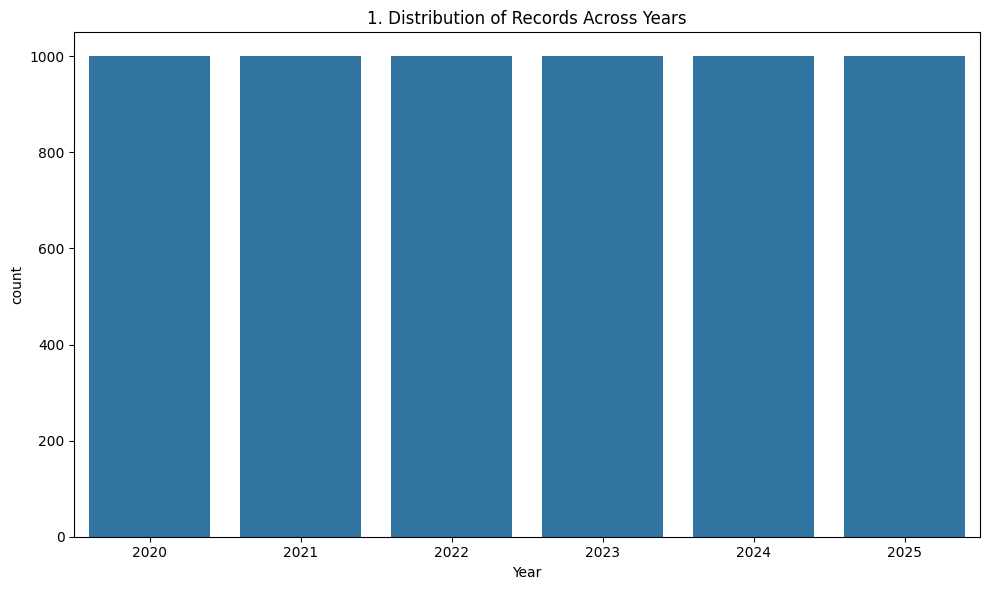

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Year', data=df)
plt.title(f'{plot_no}. Distribution of Records Across Years')
show_fig()
plot_no += 1

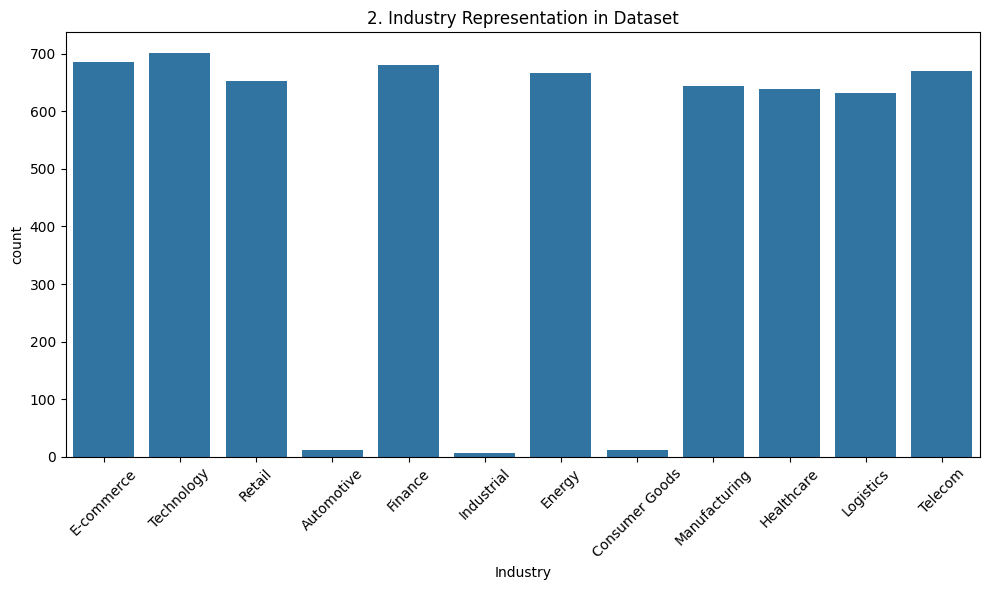

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Industry', data=df)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Industry Representation in Dataset')
show_fig()
plot_no += 1

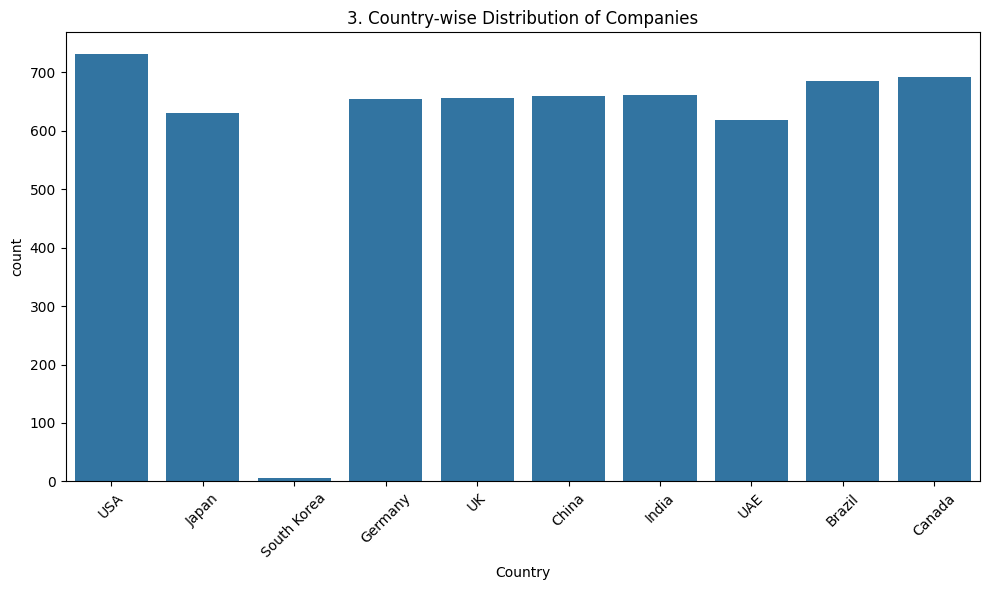

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Country', data=df)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Country-wise Distribution of Companies')
show_fig()
plot_no += 1

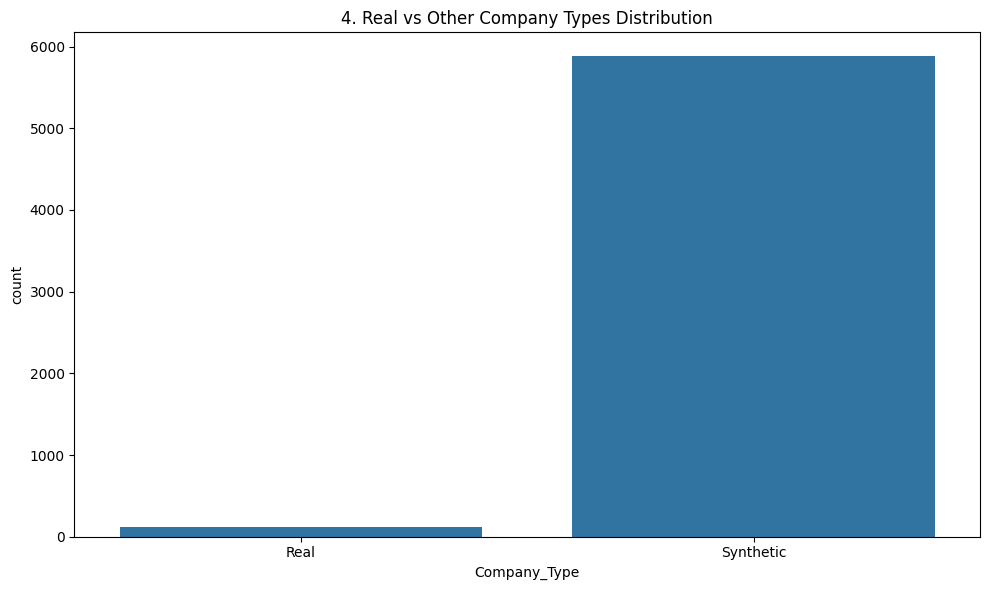

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Company_Type', data=df)
plt.title(f'{plot_no}. Real vs Other Company Types Distribution')
show_fig()
plot_no += 1

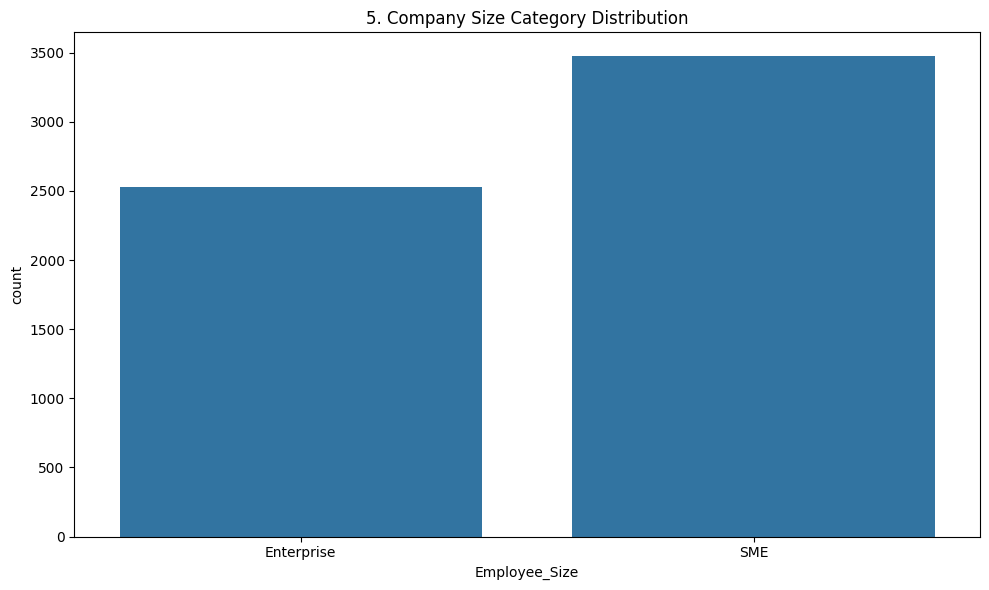

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Employee_Size', data=df)
plt.title(f'{plot_no}. Company Size Category Distribution')
show_fig()
plot_no += 1

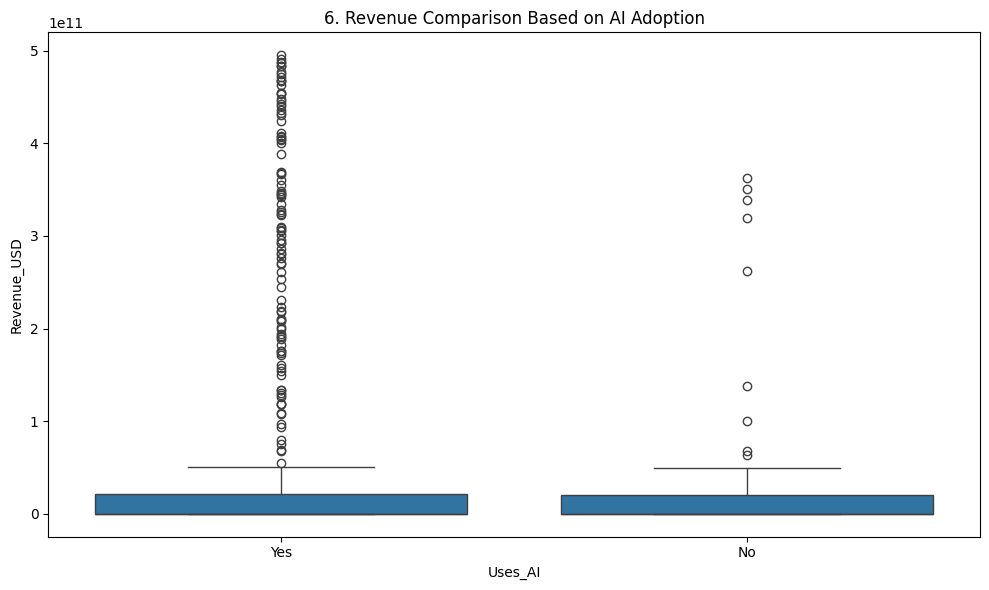

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Uses_AI', y='Revenue_USD', data=df)
plt.title(f'{plot_no}. Revenue Comparison Based on AI Adoption')
show_fig()
plot_no += 1

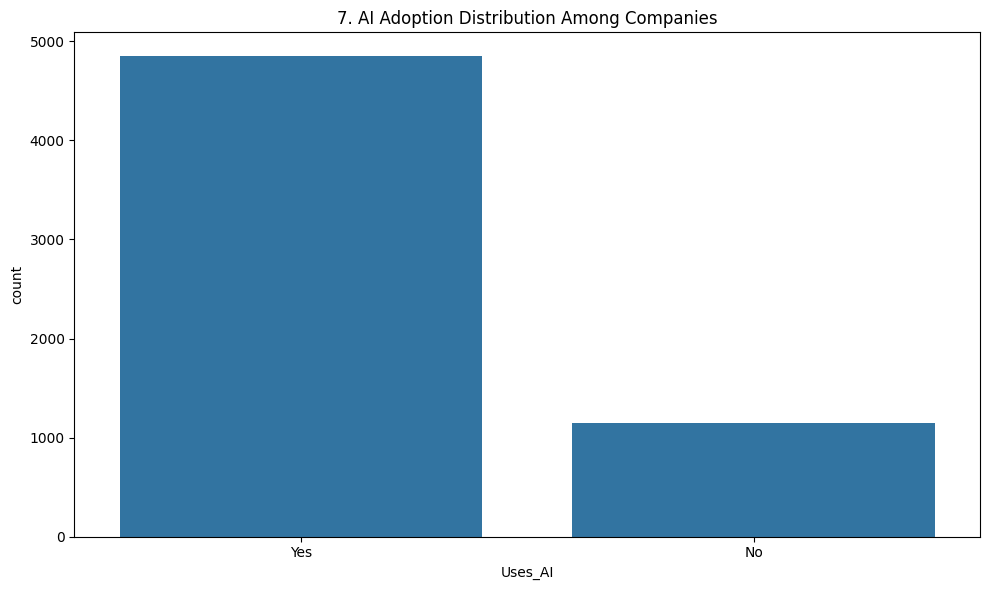

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Uses_AI', data=df)
plt.title(f'{plot_no}. AI Adoption Distribution Among Companies')
show_fig()
plot_no += 1

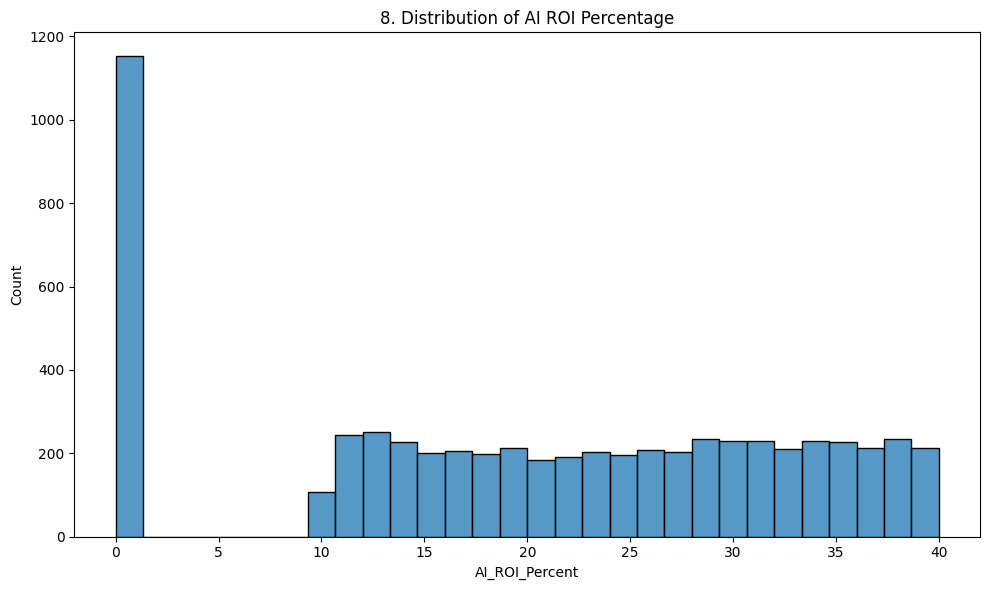

In [21]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['AI_ROI_Percent'], bins=30)
plt.title(f'{plot_no}. Distribution of AI ROI Percentage')
show_fig()
plot_no += 1

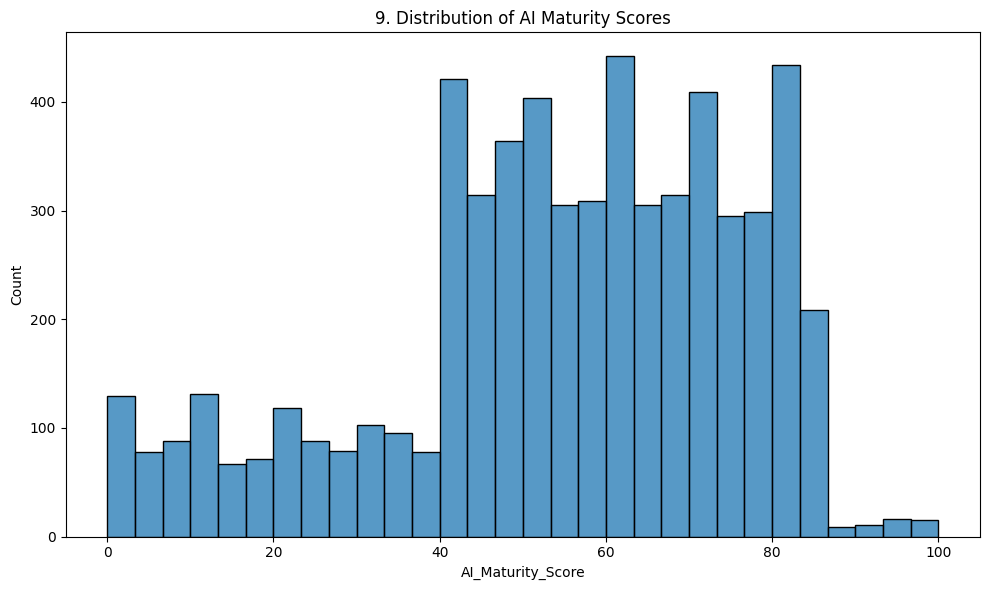

In [22]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['AI_Maturity_Score'], bins=30)
plt.title(f'{plot_no}. Distribution of AI Maturity Scores')
show_fig()
plot_no += 1

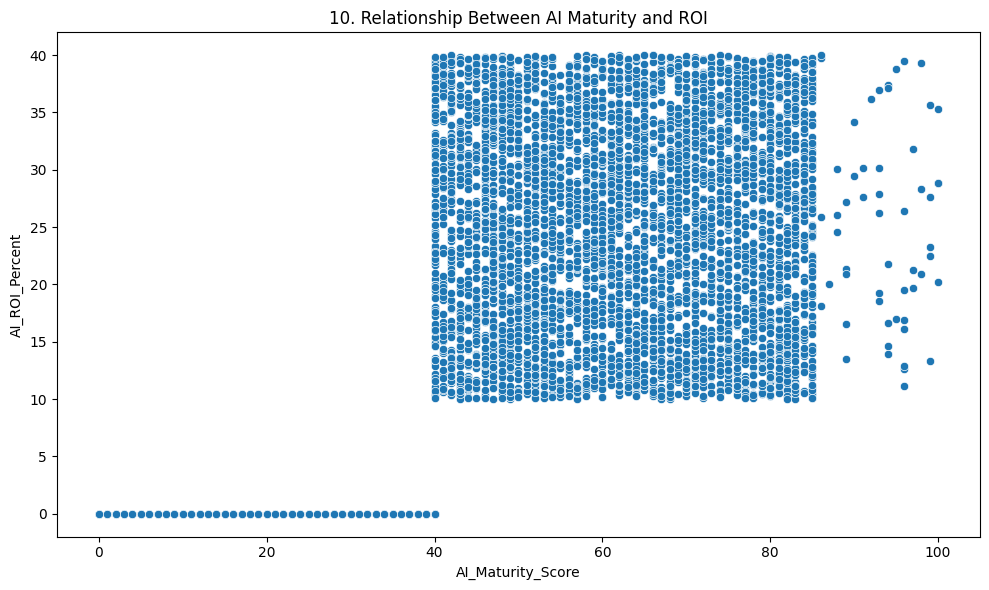

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='AI_Maturity_Score', y='AI_ROI_Percent', data=df)
plt.title(f'{plot_no}. Relationship Between AI Maturity and ROI')
show_fig()
plot_no += 1

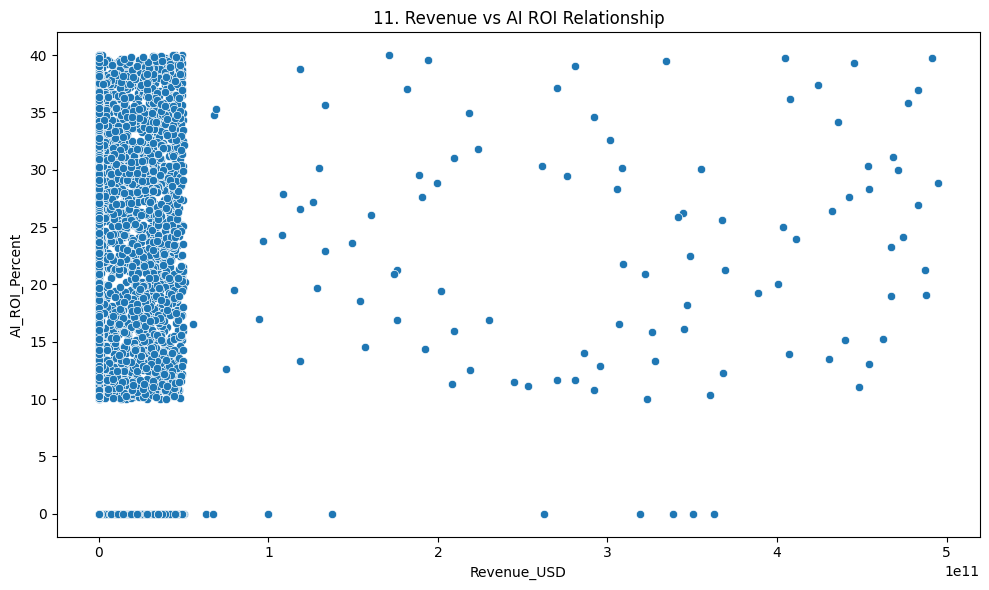

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Revenue_USD', y='AI_ROI_Percent', data=df)
plt.title(f'{plot_no}. Revenue vs AI ROI Relationship')
show_fig()
plot_no += 1

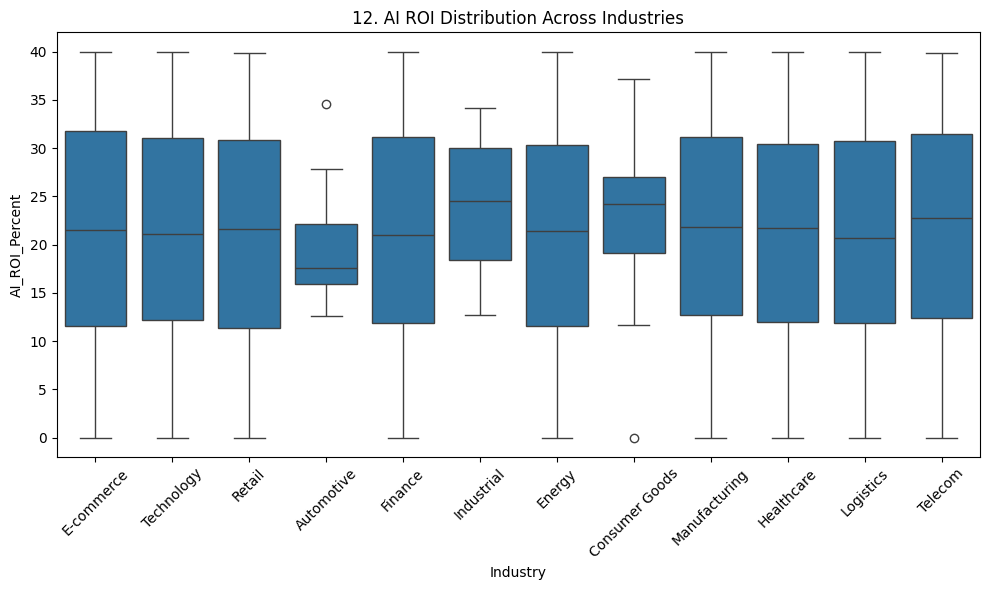

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Industry', y='AI_ROI_Percent', data=df)
plt.xticks(rotation=45)
plt.title(f'{plot_no}. AI ROI Distribution Across Industries')
show_fig()
plot_no += 1

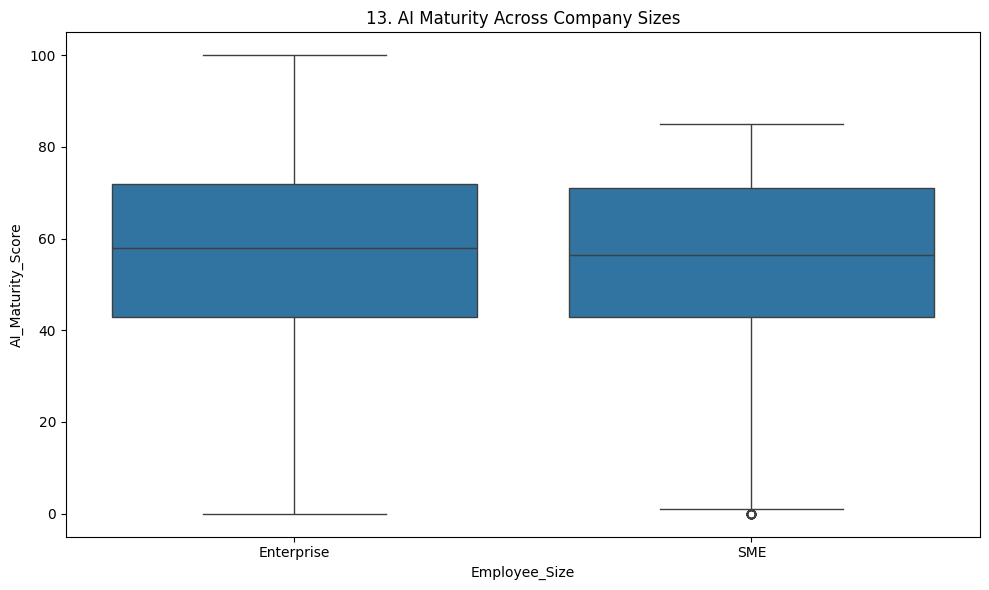

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Employee_Size', y='AI_Maturity_Score', data=df)
plt.title(f'{plot_no}. AI Maturity Across Company Sizes')
show_fig()
plot_no += 1

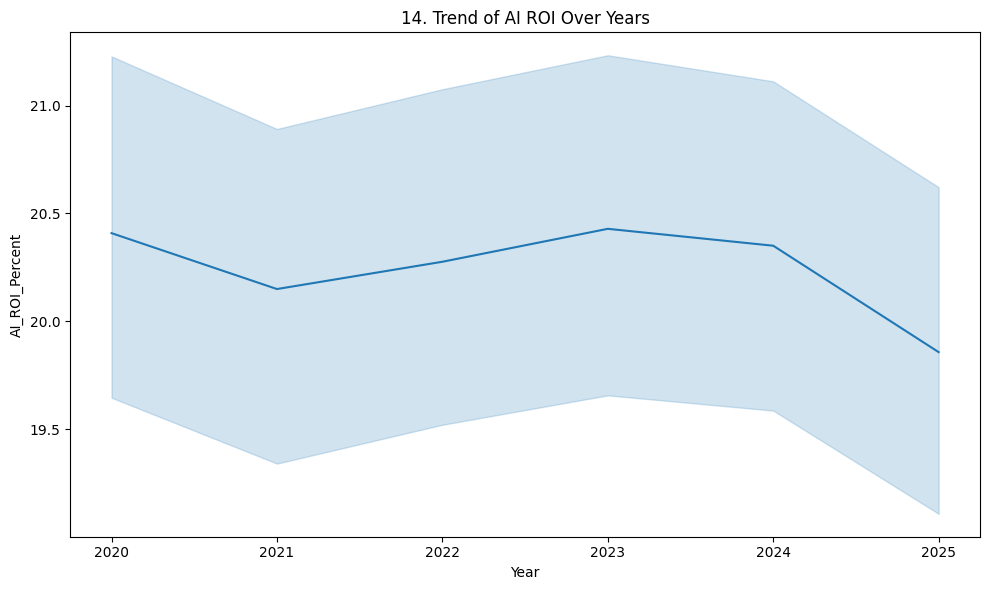

In [27]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x='Year', y='AI_ROI_Percent', data=df)
plt.title(f'{plot_no}. Trend of AI ROI Over Years')
show_fig()
plot_no += 1

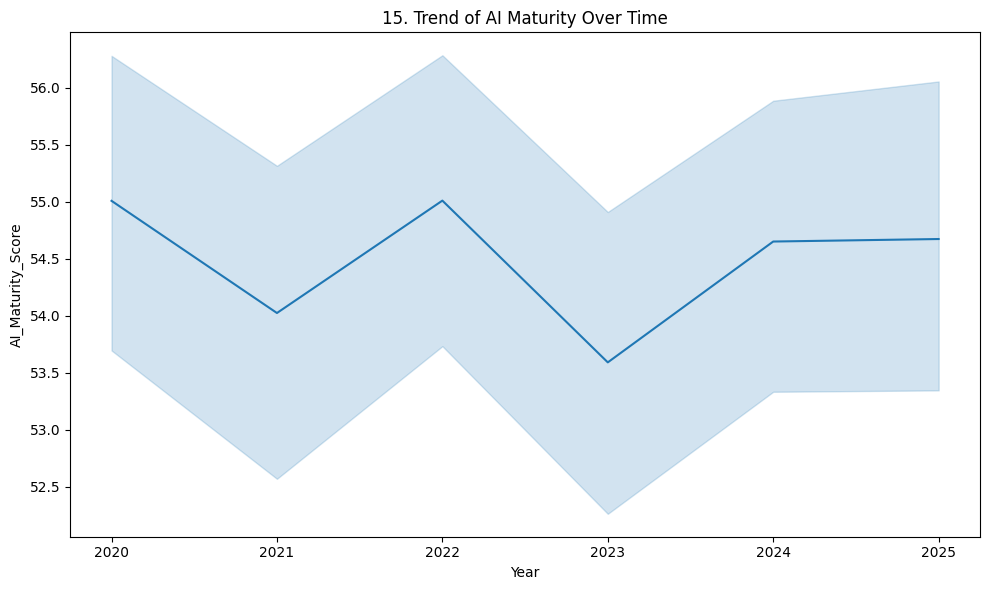

In [28]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x='Year', y='AI_Maturity_Score', data=df)
plt.title(f'{plot_no}. Trend of AI Maturity Over Time')
show_fig()
plot_no += 1

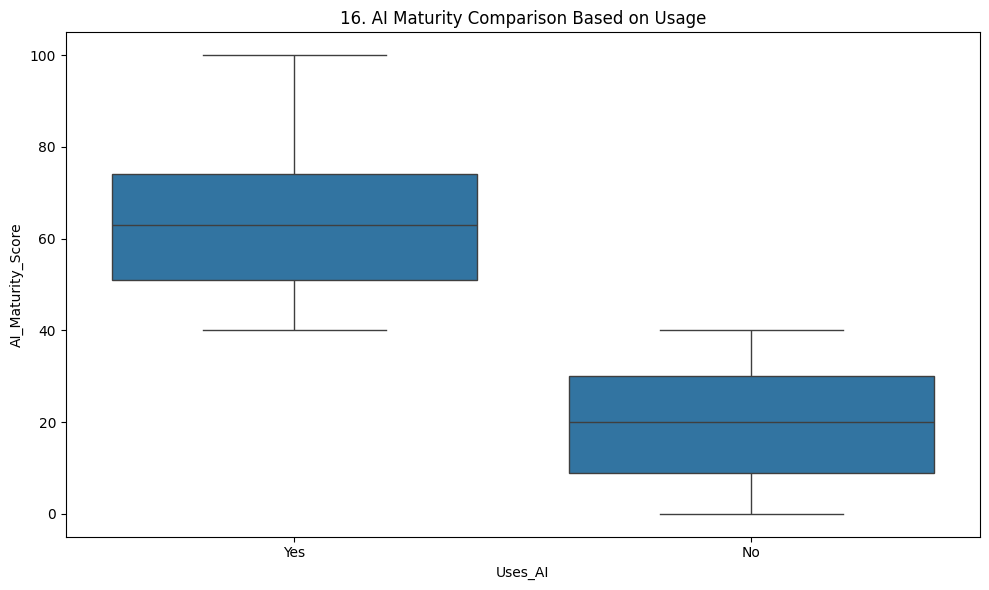

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Uses_AI', y='AI_Maturity_Score', data=df)
plt.title(f'{plot_no}. AI Maturity Comparison Based on Usage')
show_fig()
plot_no += 1

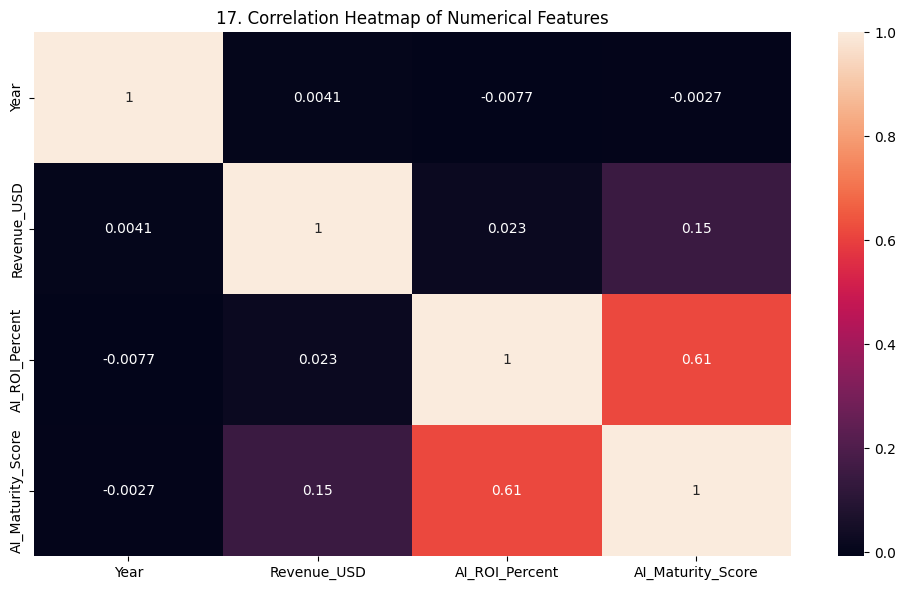

In [30]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## create target variable (AI usage classification)

In [31]:
df['Uses_AI'] = df['Uses_AI'].map({'Yes':1, 'No':0})

## select features and target

In [32]:
X = df[['Revenue_USD', 'AI_ROI_Percent', 'AI_Maturity_Score']]
y = df['Uses_AI']

## split dataset into training and testing

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## apply feature scaling

In [34]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train Logistic Regression model

In [35]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## make predictions

In [36]:
y_pred = model.predict(X_test)

## print accuracy score

In [37]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 1.0


## create confusion matrix

In [38]:
cm = confusion_matrix(y_test, y_pred)

## plot confusion matrix

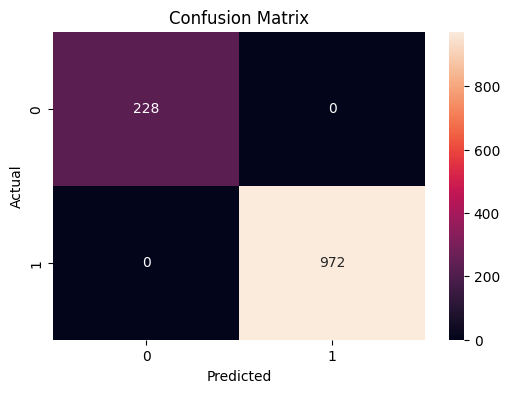

In [39]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()